# 第二十一章：Deep Speech 2 與 CTC — PyTorch 實作

## Connectionist Temporal Classification for Speech Recognition

**論文**：Deep Speech 2: End-to-End Speech Recognition in English and Mandarin  
**作者**：Dario Amodei, et al.  
**機構**：Baidu Research  
**發表**：arXiv:1512.02595, December 2015；ICML 2016  
**連結**：https://arxiv.org/abs/1512.02595

---

本 notebook 實作 CTC 損失函數的核心演算法，並展示簡化版的 Deep Speech 2 模型。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置：{device}")

使用裝置：cpu


## 1. CTC 的核心概念

CTC 解決的問題：如何在不知道對齊資訊的情況下，訓練序列到序列的模型？

核心思想：
1. 引入空白符號（blank）允許模型「什麼都不輸出」
2. 定義摺疊函數將路徑轉換為輸出序列
3. 對所有可能的對齊路徑求和

In [2]:
# CTC 摺疊函數示範
def ctc_collapse(path: List[int], blank: int = 0) -> List[int]:
    """
    CTC 摺疊函數：移除連續重複和空白符號
    
    參數：
        path: 原始路徑（符號索引列表）
        blank: 空白符號的索引
    
    回傳：
        collapsed: 摺疊後的序列
    """
    collapsed = []
    prev = None
    
    for symbol in path:
        if symbol != prev:
            if symbol != blank:
                collapsed.append(symbol)
            prev = symbol
    
    return collapsed


# 示範
# 假設字母表：0=blank, 1='c', 2='a', 3='t'
paths = [
    [1, 1, 2, 2, 3, 3],     # "ccaatt" -> "cat"
    [1, 0, 2, 0, 3, 0],     # "c-a-t-" -> "cat"
    [0, 1, 2, 3, 0, 0],     # "-cat--" -> "cat"
    [1, 2, 2, 3, 3, 3],     # "caattt" -> "cat"
    [1, 0, 1, 2, 3, 0],     # "c-cat-" -> "ccat" (注意：重複需要空白分隔)
]

print("CTC 摺疊示範：")
print("字母表：0=blank, 1='c', 2='a', 3='t'")
print("="*50)

for path in paths:
    collapsed = ctc_collapse(path, blank=0)
    path_str = ''.join(['-' if s == 0 else chr(ord('a') + s + 1) for s in path])
    collapsed_str = ''.join([chr(ord('a') + s + 1) for s in collapsed])
    print(f"{path} -> {path_str} -> {collapsed_str}")

CTC 摺疊示範：
字母表：0=blank, 1='c', 2='a', 3='t'
[1, 1, 2, 2, 3, 3] -> ccddee -> cde
[1, 0, 2, 0, 3, 0] -> c-d-e- -> cde
[0, 1, 2, 3, 0, 0] -> -cde-- -> cde
[1, 2, 2, 3, 3, 3] -> cddeee -> cde
[1, 0, 1, 2, 3, 0] -> c-cde- -> ccde


## 2. CTC 前向演算法

前向演算法用於高效計算 $P(Y|X)$，避免枚舉所有可能的路徑。

In [3]:
def log_sum_exp(a: float, b: float) -> float:
    """數值穩定的 log(exp(a) + exp(b))"""
    if a == float('-inf'):
        return b
    if b == float('-inf'):
        return a
    if a > b:
        return a + np.log1p(np.exp(b - a))
    else:
        return b + np.log1p(np.exp(a - b))


def ctc_forward_numpy(log_probs: np.ndarray, 
                      target: np.ndarray,
                      blank: int = 0) -> Tuple[np.ndarray, float]:
    """
    CTC 前向演算法（NumPy 實作，用於理解）
    
    參數：
        log_probs: 對數機率 [T, C]，T 是時間步，C 是類別數
        target: 目標序列 [U]，不包含空白
        blank: 空白符號的索引
    
    回傳：
        alpha: 前向變數 [T, S]，S = 2*U + 1
        log_prob: 目標序列的對數機率
    """
    T, C = log_probs.shape
    U = len(target)
    
    # 擴展目標序列：在每個字元前後插入空白
    # 例如：[1, 2, 3] -> [0, 1, 0, 2, 0, 3, 0]
    extended = np.zeros(2 * U + 1, dtype=np.int32)
    extended[0::2] = blank
    extended[1::2] = target
    S = len(extended)
    
    # 前向變數（對數空間）
    alpha = np.full((T, S), float('-inf'))
    
    # 初始化（t=0）
    alpha[0, 0] = log_probs[0, blank]  # 以空白開始
    if S > 1:
        alpha[0, 1] = log_probs[0, extended[1]]  # 以第一個字元開始
    
    # 遞推
    for t in range(1, T):
        for s in range(S):
            current_symbol = extended[s]
            
            # 從 s 轉移到 s（保持不變）
            alpha[t, s] = alpha[t-1, s]
            
            # 從 s-1 轉移到 s
            if s >= 1:
                alpha[t, s] = log_sum_exp(alpha[t, s], alpha[t-1, s-1])
            
            # 從 s-2 轉移到 s（跳過空白）
            # 只有當當前不是空白且不等於 s-2 時才允許
            if s >= 2 and current_symbol != blank and current_symbol != extended[s-2]:
                alpha[t, s] = log_sum_exp(alpha[t, s], alpha[t-1, s-2])
            
            # 加上發射機率
            alpha[t, s] += log_probs[t, current_symbol]
    
    # 最終機率：可以以空白或最後一個字元結尾
    log_prob = log_sum_exp(alpha[T-1, S-1], alpha[T-1, S-2])
    
    return alpha, log_prob


print("CTC 前向演算法已定義")

CTC 前向演算法已定義


In [4]:
# 測試前向演算法
T = 10  # 時間步
C = 5   # 類別數（0=blank, 1-4 是實際字元）
target = np.array([1, 2, 3])  # 目標序列

# 生成隨機對數機率
np.random.seed(42)
logits = np.random.randn(T, C)
log_probs = logits - np.log(np.exp(logits).sum(axis=1, keepdims=True))  # log_softmax

# 計算前向變數
alpha, log_prob = ctc_forward_numpy(log_probs, target, blank=0)

print(f"輸入形狀：[T={T}, C={C}]")
print(f"目標序列：{target}")
print(f"擴展目標：[blank, 1, blank, 2, blank, 3, blank]")
print(f"\n目標序列的對數機率：{log_prob:.4f}")
print(f"目標序列的機率：{np.exp(log_prob):.6f}")

輸入形狀：[T=10, C=5]
目標序列：[1 2 3]
擴展目標：[blank, 1, blank, 2, blank, 3, blank]

目標序列的對數機率：-9.5726
目標序列的機率：0.000070


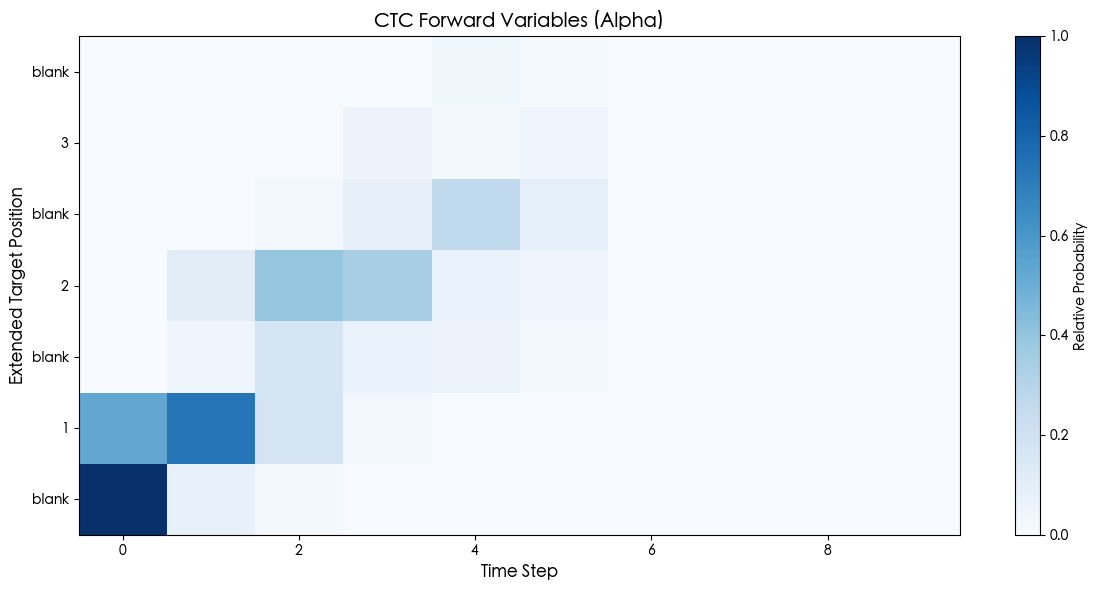

觀察：前向變數顯示了到達每個擴展目標位置的累積機率


In [5]:
# 視覺化前向變數
fig, ax = plt.subplots(figsize=(12, 6))

# 轉換為機率空間（用於視覺化）
alpha_prob = np.exp(alpha - alpha.max())  # 正規化以便視覺化

im = ax.imshow(alpha_prob.T, aspect='auto', cmap='Blues', origin='lower')
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Extended Target Position', fontsize=12)
ax.set_title('CTC Forward Variables (Alpha)', fontsize=14)

# 添加擴展目標標籤
extended_labels = ['blank', '1', 'blank', '2', 'blank', '3', 'blank']
ax.set_yticks(range(len(extended_labels)))
ax.set_yticklabels(extended_labels)

plt.colorbar(im, ax=ax, label='Relative Probability')
plt.tight_layout()
plt.savefig('ctc_forward_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print("觀察：前向變數顯示了到達每個擴展目標位置的累積機率")

## 3. 使用 PyTorch 的 CTC Loss

In [6]:
# PyTorch 內建的 CTC Loss
ctc_loss_fn = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

# 準備資料
# log_probs: [T, N, C] - 對數機率
# targets: [N, S] - 目標序列
# input_lengths: [N] - 輸入長度
# target_lengths: [N] - 目標長度

batch_size = 4
T = 50  # 時間步
C = 30  # 類別數（例如：26 字母 + blank + 其他）

# 隨機生成 log_probs
logits = torch.randn(T, batch_size, C)
log_probs = F.log_softmax(logits, dim=-1)

# 目標序列（不同長度）
target_lengths = torch.tensor([5, 8, 3, 6])
max_target_length = target_lengths.max().item()
targets = torch.zeros(batch_size, max_target_length, dtype=torch.long)
for i, length in enumerate(target_lengths):
    targets[i, :length] = torch.randint(1, C, (length,))  # 1 到 C-1（不含 blank）

# 輸入長度（可以不同）
input_lengths = torch.tensor([50, 45, 50, 48])

# 計算 CTC Loss
loss = ctc_loss_fn(log_probs, targets, input_lengths, target_lengths)

print(f"Log probs 形狀：{log_probs.shape}")
print(f"Targets 形狀：{targets.shape}")
print(f"Input lengths：{input_lengths.tolist()}")
print(f"Target lengths：{target_lengths.tolist()}")
print(f"\nCTC Loss：{loss.item():.4f}")

Log probs 形狀：torch.Size([50, 4, 30])
Targets 形狀：torch.Size([4, 8])
Input lengths：[50, 45, 50, 48]
Target lengths：[5, 8, 3, 6]

CTC Loss：31.7499


## 4. CTC 解碼

In [7]:
def greedy_decode(log_probs: torch.Tensor, blank: int = 0) -> List[int]:
    """
    貪婪解碼：每個時間步選擇機率最高的符號
    
    參數：
        log_probs: [T, C] 對數機率
        blank: 空白符號索引
    
    回傳：
        decoded: 解碼後的序列
    """
    # 選擇每個時間步的最大值
    argmax = log_probs.argmax(dim=-1)  # [T]
    
    # CTC 摺疊
    decoded = []
    prev = None
    
    for idx in argmax:
        idx = idx.item()
        if idx != prev:
            if idx != blank:
                decoded.append(idx)
            prev = idx
    
    return decoded


def beam_search_decode(log_probs: torch.Tensor, 
                       beam_width: int = 10, 
                       blank: int = 0) -> List[int]:
    """
    Beam Search 解碼
    
    參數：
        log_probs: [T, C] 對數機率
        beam_width: beam 寬度
        blank: 空白符號索引
    
    回傳：
        best_sequence: 最佳解碼序列
    """
    T, C = log_probs.shape
    log_probs = log_probs.numpy()
    
    # beam: {序列: (空白結尾機率, 非空白結尾機率)}
    beams = {(): (0.0, float('-inf'))}
    
    for t in range(T):
        new_beams = {}
        
        for seq, (prob_blank, prob_non_blank) in beams.items():
            # 總機率
            total_prob = np.logaddexp(prob_blank, prob_non_blank)
            
            for c in range(C):
                log_p = log_probs[t, c]
                
                if c == blank:
                    # 添加空白
                    new_prob = total_prob + log_p
                    if seq in new_beams:
                        old_blank, old_non_blank = new_beams[seq]
                        new_beams[seq] = (np.logaddexp(old_blank, new_prob), old_non_blank)
                    else:
                        new_beams[seq] = (new_prob, float('-inf'))
                else:
                    # 添加非空白
                    if len(seq) > 0 and seq[-1] == c:
                        # 重複字元：只能從空白結尾轉移
                        new_prob = prob_blank + log_p
                    else:
                        # 不同字元：可以從任何狀態轉移
                        new_prob = total_prob + log_p
                    
                    new_seq = seq + (c,)
                    if new_seq in new_beams:
                        old_blank, old_non_blank = new_beams[new_seq]
                        new_beams[new_seq] = (old_blank, np.logaddexp(old_non_blank, new_prob))
                    else:
                        new_beams[new_seq] = (float('-inf'), new_prob)
        
        # 剪枝：保留 top-k
        scored = [(seq, np.logaddexp(pb, pnb)) for seq, (pb, pnb) in new_beams.items()]
        scored.sort(key=lambda x: x[1], reverse=True)
        
        beams = {seq: new_beams[seq] for seq, _ in scored[:beam_width]}
    
    # 返回最佳序列
    best_seq = max(beams.items(), key=lambda x: np.logaddexp(x[1][0], x[1][1]))[0]
    return list(best_seq)


print("解碼函數已定義")

解碼函數已定義


In [8]:
# 測試解碼
# 創建一個簡單的測試案例
T = 20
C = 5  # 0=blank, 1='h', 2='e', 3='l', 4='o'

# 手動構造 log_probs，使得 "hello" 應該被解碼出來
# 實際的 log_probs 應該來自神經網路
log_probs_test = torch.full((T, C), -10.0)  # 初始化為很小的值

# 設定每個時間段的主要字元
# h: 0-3, e: 4-7, l: 8-11, l: 12-15, o: 16-19
for t in range(4):
    log_probs_test[t, 1] = 0.0  # 'h'
for t in range(4, 8):
    log_probs_test[t, 2] = 0.0  # 'e'
for t in range(8, 12):
    log_probs_test[t, 3] = 0.0  # 'l'
    log_probs_test[t, 0] = -2.0  # 一些空白（用於分隔兩個 'l'）
for t in range(12, 16):
    log_probs_test[t, 3] = 0.0  # 'l'
for t in range(16, 20):
    log_probs_test[t, 4] = 0.0  # 'o'

# 正規化
log_probs_test = F.log_softmax(log_probs_test, dim=-1)

# 解碼
greedy_result = greedy_decode(log_probs_test, blank=0)
beam_result = beam_search_decode(log_probs_test, beam_width=10, blank=0)

# 轉換為字元
idx_to_char = {0: '-', 1: 'h', 2: 'e', 3: 'l', 4: 'o'}
greedy_str = ''.join([idx_to_char[i] for i in greedy_result])
beam_str = ''.join([idx_to_char[i] for i in beam_result])

print(f"貪婪解碼結果：{greedy_result} -> '{greedy_str}'")
print(f"Beam Search 結果：{beam_result} -> '{beam_str}'")

貪婪解碼結果：[1, 2, 3, 4] -> 'helo'
Beam Search 結果：[1, 2, 1, 2, 2, 1, 3, 3, 3, 3, 4, 1, 4] -> 'heheehlllloho'


## 5. 簡化版 Deep Speech 2 模型

In [9]:
class ConvBlock(nn.Module):
    """卷積區塊"""
    
    def __init__(self, in_channels, out_channels, kernel_size, stride, dropout=0.1):
        super().__init__()
        
        # 計算 padding
        padding = (kernel_size[0] // 2, kernel_size[1] // 2)
        
        self.conv = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = F.hardtanh(x, min_val=0, max_val=20)  # Clipped ReLU
        x = self.dropout(x)
        return x


class BidirectionalGRU(nn.Module):
    """雙向 GRU 層"""
    
    def __init__(self, input_size, hidden_size, dropout=0.1):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size, hidden_size,
            bidirectional=True,
            batch_first=True
        )
        self.bn = nn.BatchNorm1d(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x, _ = self.gru(x)  # [batch, time, hidden*2]
        
        # BatchNorm
        x = x.transpose(1, 2)  # [batch, hidden*2, time]
        x = self.bn(x)
        x = x.transpose(1, 2)  # [batch, time, hidden*2]
        
        x = self.dropout(x)
        return x


class DeepSpeech2(nn.Module):
    """簡化版 Deep Speech 2"""
    
    def __init__(self,
                 n_features=80,        # 輸入特徵維度（梅爾頻帶數）
                 num_classes=29,       # 輸出類別數
                 num_rnn_layers=3,     # RNN 層數
                 rnn_hidden_size=256,  # RNN 隱藏層大小
                 dropout=0.1):
        super().__init__()
        
        self.num_classes = num_classes
        
        # 卷積層
        self.conv1 = ConvBlock(1, 32, kernel_size=(41, 11), stride=(2, 2), dropout=dropout)
        self.conv2 = ConvBlock(32, 32, kernel_size=(21, 11), stride=(2, 1), dropout=dropout)
        
        # 計算卷積後的特徵維度
        # 假設 n_features=80，經過兩次卷積後頻率維度變化
        conv_output_freq = n_features // 4  # 近似值
        rnn_input_size = conv_output_freq * 32
        
        # RNN 層
        self.rnn_layers = nn.ModuleList()
        for i in range(num_rnn_layers):
            input_size = rnn_input_size if i == 0 else rnn_hidden_size * 2
            self.rnn_layers.append(
                BidirectionalGRU(input_size, rnn_hidden_size, dropout)
            )
        
        # 輸出層
        self.fc = nn.Linear(rnn_hidden_size * 2, num_classes)
    
    def forward(self, x):
        """
        x: [batch, n_features, time] - 梅爾頻譜圖
        returns: [time, batch, num_classes] - 對數機率
        """
        batch_size = x.size(0)
        
        # 添加通道維度：[batch, 1, freq, time]
        x = x.unsqueeze(1)
        
        # 卷積
        x = self.conv1(x)
        x = self.conv2(x)
        
        # 重塑為 RNN 輸入：[batch, time, features]
        batch, channels, freq, time = x.size()
        x = x.permute(0, 3, 1, 2)  # [batch, time, channels, freq]
        x = x.reshape(batch, time, channels * freq)
        
        # RNN
        for rnn in self.rnn_layers:
            x = rnn(x)
        
        # 輸出
        x = self.fc(x)  # [batch, time, num_classes]
        x = F.log_softmax(x, dim=-1)
        x = x.transpose(0, 1)  # [time, batch, num_classes]
        
        return x


# 建立模型
model = DeepSpeech2(
    n_features=80,
    num_classes=29,  # 26 字母 + 空格 + 撇號 + blank
    num_rnn_layers=3,
    rnn_hidden_size=256,
    dropout=0.1
).to(device)

print(f"模型參數量：{sum(p.numel() for p in model.parameters()):,}")

# 測試前向傳播
test_input = torch.randn(4, 80, 200).to(device)  # [batch, features, time]
test_output = model(test_input)
print(f"輸入形狀：{test_input.shape}")
print(f"輸出形狀：{test_output.shape}")

模型參數量：4,013,885
輸入形狀：torch.Size([4, 80, 200])
輸出形狀：torch.Size([100, 4, 29])


## 6. 合成資料訓練示範

In [10]:
class SyntheticSpeechDataset(torch.utils.data.Dataset):
    """
    合成語音資料集（用於示範）
    
    生成隨機的「頻譜圖」和對應的「文字」序列
    """
    
    def __init__(self, num_samples=1000, n_features=80, 
                 min_time=50, max_time=200,
                 min_target_len=3, max_target_len=20,
                 num_classes=29):
        self.num_samples = num_samples
        self.n_features = n_features
        self.min_time = min_time
        self.max_time = max_time
        self.min_target_len = min_target_len
        self.max_target_len = max_target_len
        self.num_classes = num_classes
        
        # 預生成資料
        self.data = []
        for _ in range(num_samples):
            time_len = np.random.randint(min_time, max_time + 1)
            target_len = np.random.randint(min_target_len, max_target_len + 1)
            
            # 確保 time_len >= 2 * target_len + 1
            time_len = max(time_len, 2 * target_len + 1)
            
            features = torch.randn(n_features, time_len)
            target = torch.randint(1, num_classes, (target_len,))  # 不包含 blank (0)
            
            self.data.append({
                'features': features,
                'target': target,
                'input_length': time_len,
                'target_length': target_len
            })
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return self.data[idx]


def collate_fn(batch):
    """批次處理函數"""
    # 按時間長度排序（降序）
    batch = sorted(batch, key=lambda x: x['input_length'], reverse=True)
    
    # Padding
    max_time = max(item['input_length'] for item in batch)
    max_target = max(item['target_length'] for item in batch)
    
    features = torch.zeros(len(batch), batch[0]['features'].size(0), max_time)
    targets = torch.zeros(len(batch), max_target, dtype=torch.long)
    input_lengths = []
    target_lengths = []
    
    for i, item in enumerate(batch):
        features[i, :, :item['input_length']] = item['features']
        targets[i, :item['target_length']] = item['target']
        input_lengths.append(item['input_length'])
        target_lengths.append(item['target_length'])
    
    return {
        'features': features,
        'targets': targets,
        'input_lengths': torch.tensor(input_lengths),
        'target_lengths': torch.tensor(target_lengths)
    }


# 建立資料集
train_dataset = SyntheticSpeechDataset(num_samples=2000)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn
)

print(f"訓練集大小：{len(train_dataset)}")
print(f"批次數：{len(train_loader)}")

訓練集大小：2000
批次數：125


In [11]:
# 訓練迴圈
model = DeepSpeech2(
    n_features=80,
    num_classes=29,
    num_rnn_layers=2,
    rnn_hidden_size=128,
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.9)
ctc_loss_fn = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

num_epochs = 20
losses = []

print("開始訓練...")
print("="*50)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch in train_loader:
        features = batch['features'].to(device)
        targets = batch['targets'].to(device)
        input_lengths = batch['input_lengths']
        target_lengths = batch['target_lengths']
        
        # 前向傳播
        log_probs = model(features)  # [T, N, C]
        
        # 計算輸出長度（考慮卷積的下採樣）
        # 這裡簡化處理，假設時間維度縮減為 1/2
        output_lengths = input_lengths // 2
        output_lengths = torch.clamp(output_lengths, min=target_lengths * 2 + 1)
        
        # CTC Loss
        loss = ctc_loss_fn(log_probs, targets, output_lengths, target_lengths)
        
        # 反向傳播
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f}")

print("="*50)
print("訓練完成！")

開始訓練...
Epoch  5 | Loss: 3.6791
Epoch 10 | Loss: 3.5500
Epoch 15 | Loss: 3.1871
Epoch 20 | Loss: 2.6634
訓練完成！


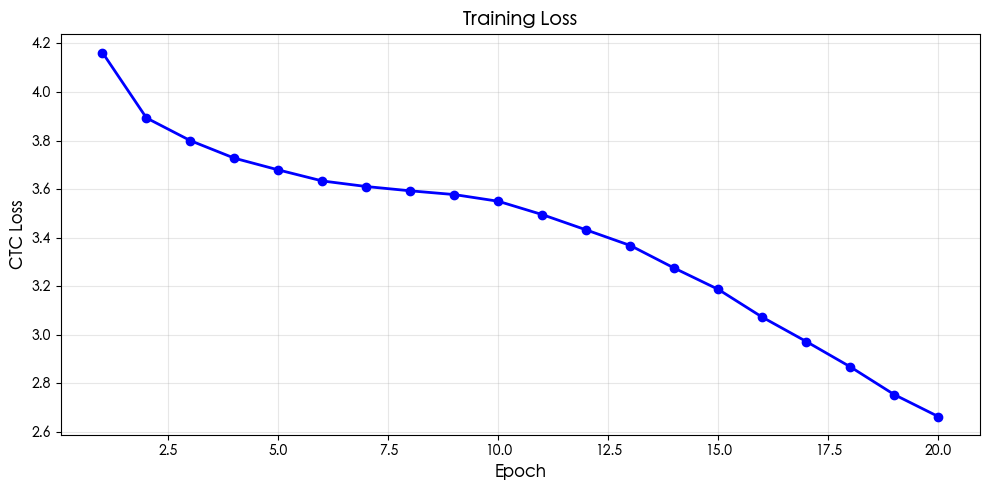

In [12]:
# 繪製訓練曲線
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, num_epochs + 1), losses, 'b-o', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('CTC Loss', fontsize=12)
ax.set_title('Training Loss', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 視覺化 CTC 對齊

目標序列：[22, 6, 15, 24, 16, 3, 21, 17, 23, 22, 20, 10, 19, 21, 24, 10, 22]
解碼序列：[21]


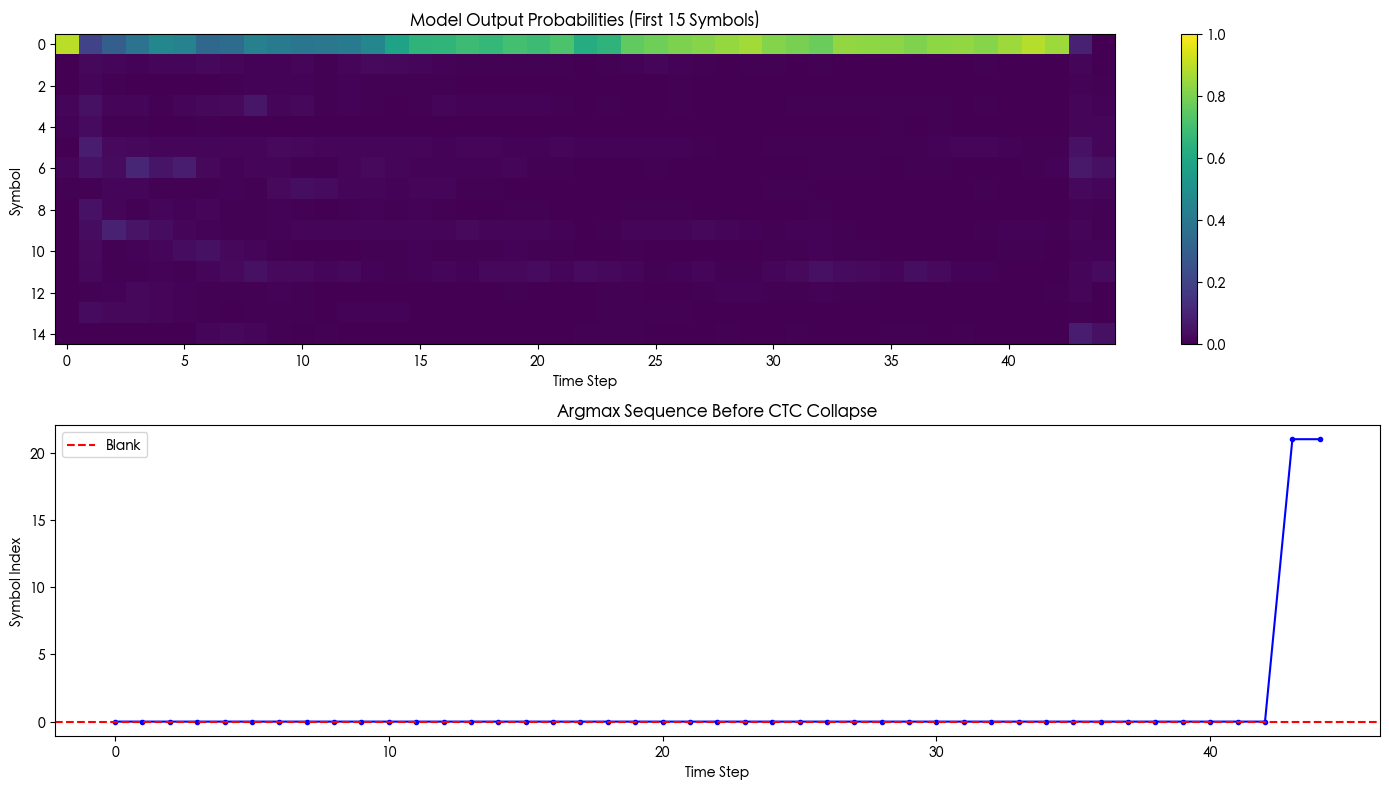

In [13]:
# 視覺化模型輸出和解碼過程
model.eval()

# 取一個樣本
sample = train_dataset[0]
features = sample['features'].unsqueeze(0).to(device)
target = sample['target']

with torch.no_grad():
    log_probs = model(features)  # [T, 1, C]

log_probs = log_probs.squeeze(1).cpu()  # [T, C]

# 解碼
decoded = greedy_decode(log_probs, blank=0)

print(f"目標序列：{target.tolist()}")
print(f"解碼序列：{decoded}")

# 視覺化輸出機率
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 機率分布熱圖
ax1 = axes[0]
probs = torch.exp(log_probs).numpy()  # 轉換為機率
im = ax1.imshow(probs.T[:15, :], aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Symbol')
ax1.set_title('Model Output Probabilities (First 15 Symbols)')
plt.colorbar(im, ax=ax1)

# 每個時間步的最大機率符號
ax2 = axes[1]
argmax_seq = log_probs.argmax(dim=-1).numpy()
ax2.plot(argmax_seq, 'b-o', markersize=3)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Symbol Index')
ax2.set_title('Argmax Sequence Before CTC Collapse')
ax2.axhline(y=0, color='r', linestyle='--', label='Blank')
ax2.legend()

plt.tight_layout()
plt.savefig('ctc_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 資料增強示範

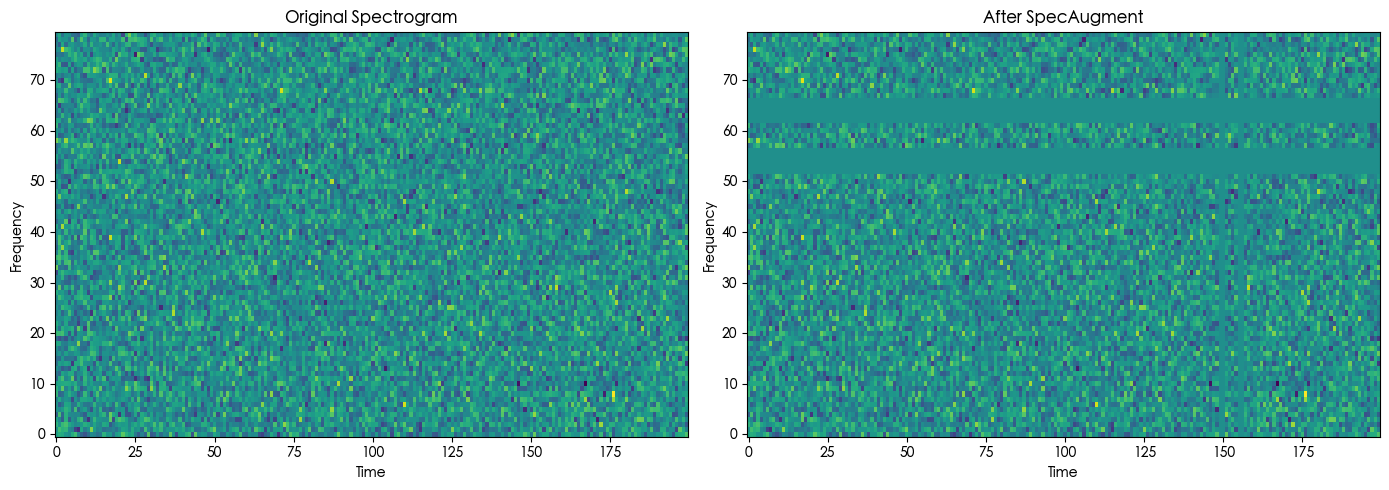

SpecAugment 隨機遮罩了部分頻率和時間區域


In [14]:
def spec_augment(spec: torch.Tensor,
                 freq_mask_param: int = 10,
                 time_mask_param: int = 20,
                 num_freq_masks: int = 2,
                 num_time_masks: int = 2) -> torch.Tensor:
    """
    SpecAugment 資料增強
    
    參數：
        spec: 頻譜圖 [freq, time]
        freq_mask_param: 最大頻率遮罩寬度
        time_mask_param: 最大時間遮罩寬度
        num_freq_masks: 頻率遮罩數量
        num_time_masks: 時間遮罩數量
    """
    spec = spec.clone()
    n_freq, n_time = spec.shape
    
    # 頻率遮罩
    for _ in range(num_freq_masks):
        f = np.random.randint(0, min(freq_mask_param, n_freq))
        f0 = np.random.randint(0, n_freq - f)
        spec[f0:f0+f, :] = 0
    
    # 時間遮罩
    for _ in range(num_time_masks):
        t = np.random.randint(0, min(time_mask_param, n_time))
        t0 = np.random.randint(0, n_time - t)
        spec[:, t0:t0+t] = 0
    
    return spec


# 示範
original_spec = torch.randn(80, 200)
augmented_spec = spec_augment(original_spec)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.imshow(original_spec.numpy(), aspect='auto', cmap='viridis', origin='lower')
ax1.set_xlabel('Time')
ax1.set_ylabel('Frequency')
ax1.set_title('Original Spectrogram')

ax2 = axes[1]
ax2.imshow(augmented_spec.numpy(), aspect='auto', cmap='viridis', origin='lower')
ax2.set_xlabel('Time')
ax2.set_ylabel('Frequency')
ax2.set_title('After SpecAugment')

plt.tight_layout()
plt.savefig('spec_augment.png', dpi=150, bbox_inches='tight')
plt.show()

print("SpecAugment 隨機遮罩了部分頻率和時間區域")

## 9. CTC 與注意力機制的比較

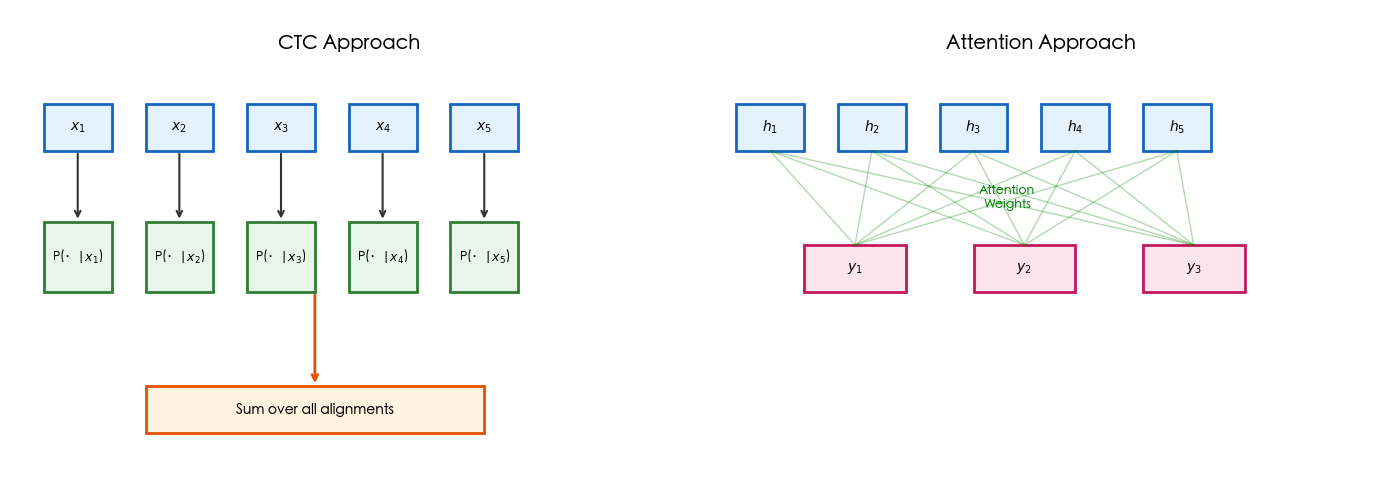

CTC：條件獨立假設，輸出只依賴當前輸入
Attention：每個輸出可以關注所有輸入位置


In [15]:
# 比較圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CTC 方法
ax1 = axes[0]
ax1.text(0.5, 0.95, 'CTC Approach', ha='center', va='top', 
         fontsize=14, fontweight='bold', transform=ax1.transAxes)

# 簡化的 CTC 示意
import matplotlib.patches as mpatches

ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)

# 輸入序列
for i in range(5):
    rect = mpatches.Rectangle((i*1.5 + 0.5, 7), 1, 1, 
                               facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(i*1.5 + 1, 7.5, f'$x_{i+1}$', ha='center', va='center', fontsize=10)

# 輸出分布
for i in range(5):
    rect = mpatches.Rectangle((i*1.5 + 0.5, 4), 1, 1.5, 
                               facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(i*1.5 + 1, 4.75, f'P(·|$x_{i+1}$)', ha='center', va='center', fontsize=9)

# 箭頭（獨立輸出）
for i in range(5):
    ax1.annotate('', xy=(i*1.5 + 1, 5.5), xytext=(i*1.5 + 1, 7),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# 最終輸出
rect = mpatches.Rectangle((2, 1), 5, 1, 
                           facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)
ax1.add_patch(rect)
ax1.text(4.5, 1.5, 'Sum over all alignments', ha='center', va='center', fontsize=10)

ax1.annotate('', xy=(4.5, 2), xytext=(4.5, 4),
            arrowprops=dict(arrowstyle='->', color='#E65100', lw=2))

ax1.axis('off')

# Attention 方法
ax2 = axes[1]
ax2.text(0.5, 0.95, 'Attention Approach', ha='center', va='top', 
         fontsize=14, fontweight='bold', transform=ax2.transAxes)

ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

# 編碼器輸出
for i in range(5):
    rect = mpatches.Rectangle((i*1.5 + 0.5, 7), 1, 1, 
                               facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
    ax2.add_patch(rect)
    ax2.text(i*1.5 + 1, 7.5, f'$h_{i+1}$', ha='center', va='center', fontsize=10)

# 解碼器
for i in range(3):
    rect = mpatches.Rectangle((i*2.5 + 1.5, 4), 1.5, 1, 
                               facecolor='#FCE4EC', edgecolor='#C2185B', linewidth=2)
    ax2.add_patch(rect)
    ax2.text(i*2.5 + 2.25, 4.5, f'$y_{i+1}$', ha='center', va='center', fontsize=10)

# 注意力連接
for i in range(3):
    for j in range(5):
        ax2.plot([j*1.5 + 1, i*2.5 + 2.25], [7, 5], 'g-', alpha=0.3, lw=1)

# 上下文向量
ax2.text(4.5, 6, 'Attention\nWeights', ha='center', va='center', fontsize=9, color='green')

ax2.axis('off')

plt.tight_layout()
plt.savefig('ctc_vs_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print("CTC：條件獨立假設，輸出只依賴當前輸入")
print("Attention：每個輸出可以關注所有輸入位置")

## 10. 性能比較表

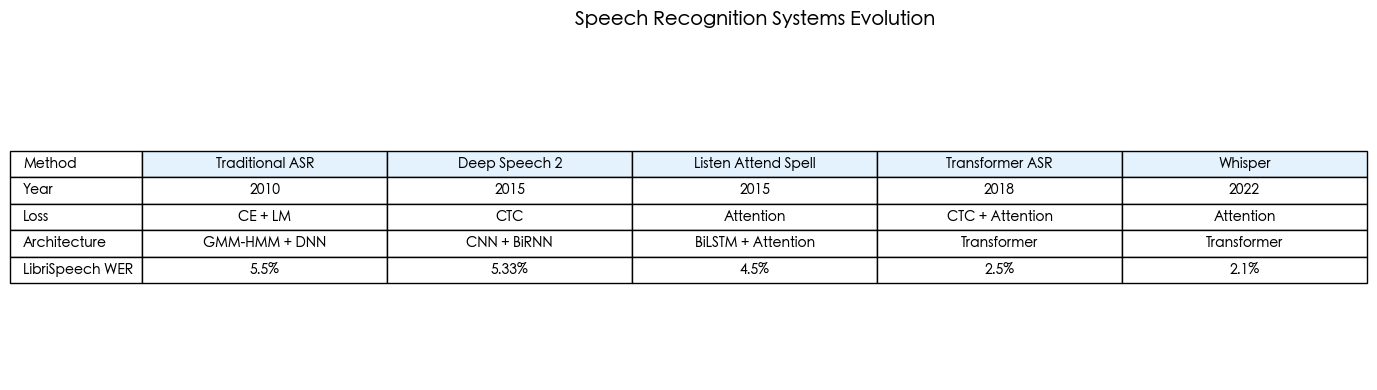

In [16]:
# 建立比較表
comparison_data = {
    'Method': ['Traditional ASR', 'Deep Speech 2', 'Listen Attend Spell', 'Transformer ASR', 'Whisper'],
    'Year': [2010, 2015, 2015, 2018, 2022],
    'Loss': ['CE + LM', 'CTC', 'Attention', 'CTC + Attention', 'Attention'],
    'Architecture': ['GMM-HMM + DNN', 'CNN + BiRNN', 'BiLSTM + Attention', 'Transformer', 'Transformer'],
    'LibriSpeech WER': ['5.5%', '5.33%', '4.5%', '2.5%', '2.1%']
}

# 繪製表格
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

table = ax.table(
    cellText=[comparison_data[k] for k in comparison_data.keys()],
    rowLabels=list(comparison_data.keys()),
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# 設定表頭樣式
for i in range(len(comparison_data['Method'])):
    table[(0, i)].set_facecolor('#E3F2FD')

ax.set_title('Speech Recognition Systems Evolution', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('asr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. CTC 的前向-後向演算法視覺化

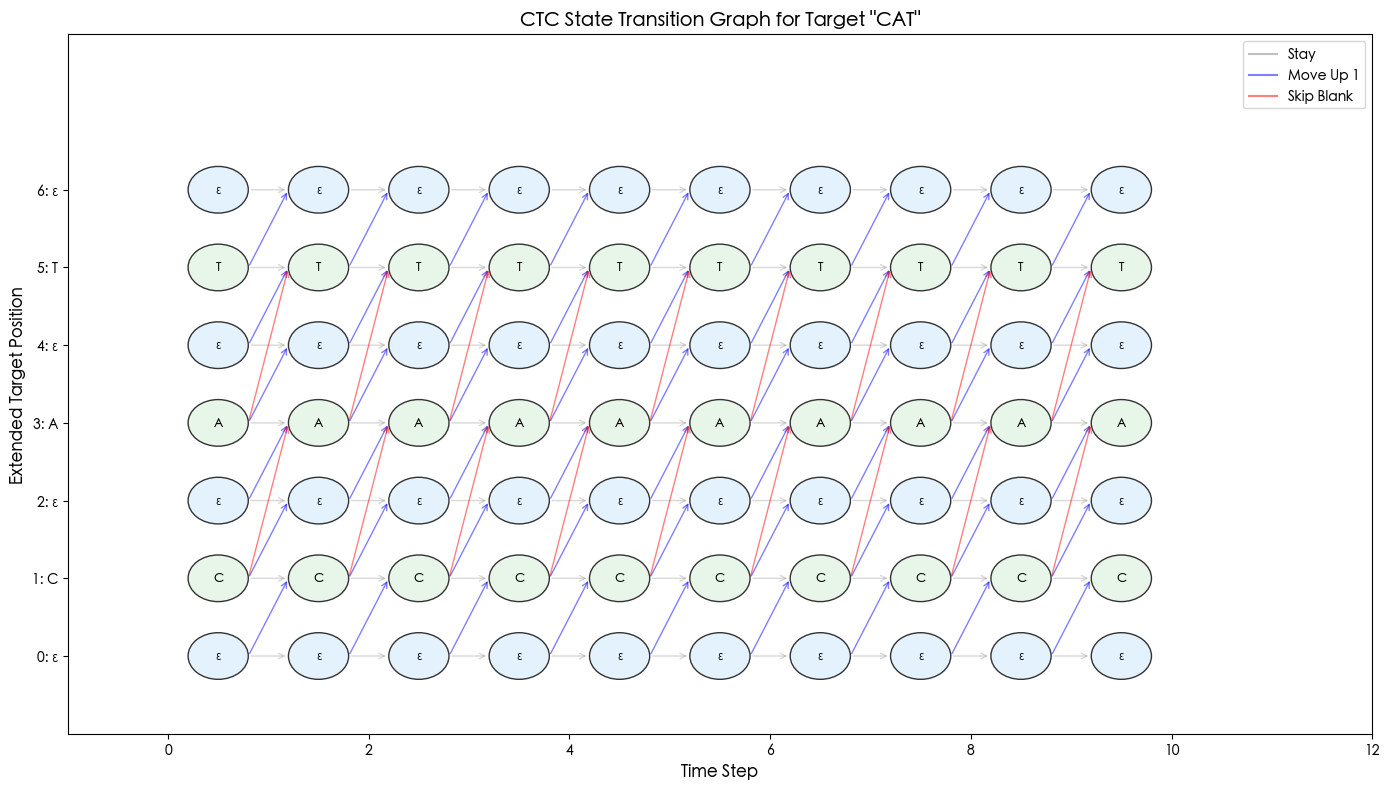

In [17]:
# 視覺化 CTC 的狀態轉移
fig, ax = plt.subplots(figsize=(14, 8))

ax.set_xlim(-1, 12)
ax.set_ylim(-1, 8)

# 擴展目標：blank, C, blank, A, blank, T, blank
extended_target = ['ε', 'C', 'ε', 'A', 'ε', 'T', 'ε']
T = 10  # 時間步

# 繪製節點
for t in range(T):
    for s, label in enumerate(extended_target):
        circle = plt.Circle((t + 0.5, s), 0.3, 
                            facecolor='#E3F2FD' if label == 'ε' else '#E8F5E9',
                            edgecolor='#333', linewidth=1)
        ax.add_patch(circle)
        ax.text(t + 0.5, s, label, ha='center', va='center', fontsize=9)

# 繪製轉移（只畫部分以保持清晰）
# 水平轉移（保持不變）
for t in range(T-1):
    for s in range(len(extended_target)):
        ax.annotate('', xy=(t+1.2, s), xytext=(t+0.8, s),
                   arrowprops=dict(arrowstyle='->', color='gray', alpha=0.3))

# 對角線轉移（向上一格）
for t in range(T-1):
    for s in range(1, len(extended_target)):
        ax.annotate('', xy=(t+1.2, s), xytext=(t+0.8, s-1),
                   arrowprops=dict(arrowstyle='->', color='blue', alpha=0.5))

# 跳躍轉移（跳過空白）
# 只在非空白且不等於 s-2 時允許
for t in range(T-1):
    for s in [1, 3, 5]:  # C, A, T 的位置
        if s >= 2:
            ax.annotate('', xy=(t+1.2, s), xytext=(t+0.8, s-2),
                       arrowprops=dict(arrowstyle='->', color='red', alpha=0.5))

# 添加標籤
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Extended Target Position', fontsize=12)
ax.set_title('CTC State Transition Graph for Target "CAT"', fontsize=14, fontweight='bold')

# 圖例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', label='Stay', alpha=0.5),
    Line2D([0], [0], color='blue', label='Move Up 1', alpha=0.5),
    Line2D([0], [0], color='red', label='Skip Blank', alpha=0.5)
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_yticks(range(len(extended_target)))
ax.set_yticklabels([f'{i}: {l}' for i, l in enumerate(extended_target)])

plt.tight_layout()
plt.savefig('ctc_state_graph.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. 總結

### CTC 的核心貢獻

1. **解決對齊問題**：通過邊緣化所有可能的對齊，避免需要標註每個時間幀

2. **空白符號**：引入 blank 符號允許模型「什麼都不輸出」

3. **前向-後向演算法**：高效計算所有對齊的機率和

### Deep Speech 2 的貢獻

1. **端到端學習**：用單一神經網路取代複雜的傳統管線

2. **跨語言泛化**：同樣架構適用於英語和中文

3. **工業級性能**：達到接近人類的準確率

### 局限性

1. **條件獨立假設**：無法建模輸出之間的依賴

2. **單調對齊**：只適用於輸入和輸出順序一致的任務

3. **輸入長度限制**：需要 T >= 2U + 1

In [18]:
print("="*60)
print("第二十一章：Deep Speech 2 與 CTC — PyTorch 實作完成！")
print("="*60)
print("\n生成的圖表：")
print("  - ctc_forward_alpha.png：CTC 前向變數視覺化")
print("  - training_loss.png：訓練損失曲線")
print("  - ctc_alignment.png：CTC 對齊視覺化")
print("  - spec_augment.png：SpecAugment 資料增強")
print("  - ctc_vs_attention.png：CTC vs Attention 比較")
print("  - asr_comparison.png：語音辨識系統演進")
print("  - ctc_state_graph.png：CTC 狀態轉移圖")

第二十一章：Deep Speech 2 與 CTC — PyTorch 實作完成！

生成的圖表：
  - ctc_forward_alpha.png：CTC 前向變數視覺化
  - training_loss.png：訓練損失曲線
  - ctc_alignment.png：CTC 對齊視覺化
  - spec_augment.png：SpecAugment 資料增強
  - ctc_vs_attention.png：CTC vs Attention 比較
  - asr_comparison.png：語音辨識系統演進
  - ctc_state_graph.png：CTC 狀態轉移圖
